In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 102.8 MB/s eta 0:00:00


In [ ]:
!uv pip install torch
!uv pip install pillow
!uv pip install -q diffusers transformers accelerate bitsandbytes
!uv pip install -q peft xformers
!uv pip install -q datasets huggingface_hub

Using Python 3.12.12 environment at: /usr
Audited 1 package in 119ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 90ms


In [ ]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA L4
VRAM: 23.7 GB


In [ ]:
import os
import torch
from tqdm import tqdm
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

def generate_synthetic_images(
    model_id: str,
    prompt: str,
    output_dir: str,
    num_images: int = 1200,
    batch_size: int = 8,
    num_inference_steps: int = 50,
    guidance_scale: float = 4.0,
):
    """Generate synthetic chest X-ray images from finetuned model."""

    print(f"\n{'='*60}")
    print(f"Loading model: {model_id}")
    print(f"{'='*60}")

    # Load the finetuned model
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        safety_checker=None,
    ).to("cuda")

    # Use faster scheduler
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    # Enable memory optimizations (optional, helps on lower VRAM)
    pipe.enable_attention_slicing()

    os.makedirs(output_dir, exist_ok=True)

    print(f"Generating {num_images} images...")
    print(f"Prompt: '{prompt}'")
    print(f"Output: {output_dir}")

    generated = 0
    pbar = tqdm(total=num_images, desc="Generating")

    while generated < num_images:
        current_batch = min(batch_size, num_images - generated)

        # Generate batch
        images = pipe(
            [prompt] * current_batch,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=torch.Generator("cuda").manual_seed(generated),
        ).images

        # Save images
        for i, img in enumerate(images):
            img.save(f"{output_dir}/synthetic_{generated + i:05d}.png")

        generated += current_batch
        pbar.update(current_batch)

    pbar.close()

    # Free up memory
    del pipe
    torch.cuda.empty_cache()

    print(f"Saved {num_images} images to {output_dir}")
    return output_dir

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
generate_synthetic_images(
    model_id="chimbiwide/cxr-normal-dreambooth",
    prompt="A chest xray of healthy normal lungs, clear lung fields",
    output_dir="./synthetic_data/normal",
    num_images=1200,
    batch_size=16,  # Adjust based on your GPU memory
)

# Generate PNEUMONIA chest X-rays (1200 images)
generate_synthetic_images(
    model_id="chimbiwide/cxr-pneumonia-dreambooth",
    prompt="A chest xray showing pneumonia infection, lung opacity",
    output_dir="./synthetic_data/pneumonia",
    num_images=1200,
    batch_size=16,
)

print("\n" + "="*60)
print("ALL GENERATION COMPLETE!")
print("="*60)
print(f"Normal images: ./synthetic_data/normal/ (1200 images)")
print(f"Pneumonia images: ./synthetic_data/pneumonia/ (1200 images)")


Loading model: chimbiwide/cxr-normal-dreambooth


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Generating 1200 images...
Prompt: 'A chest xray of healthy normal lungs, clear lung fields'
Output: ./synthetic_data/normal




Generating:   0%|          | 0/1200 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]


Generating:  99%|█████████▊| 1184/1200 [1:25:29<01:09,  4.33s/it]

  0%|          | 0/50 [00:00<?, ?it/s]


Generating: 100%|██████████| 1200/1200 [1:26:38<00:00,  4.33s/it]

Saved 1200 images to ./synthetic_data/pneumonia

✅ ALL GENERATION COMPLETE!
Normal images: ./synthetic_data/normal/ (1200 images)
Pneumonia images: ./synthetic_data/pneumonia/ (1200 images)


normal: 1200 images
pneumonia: 1200 images


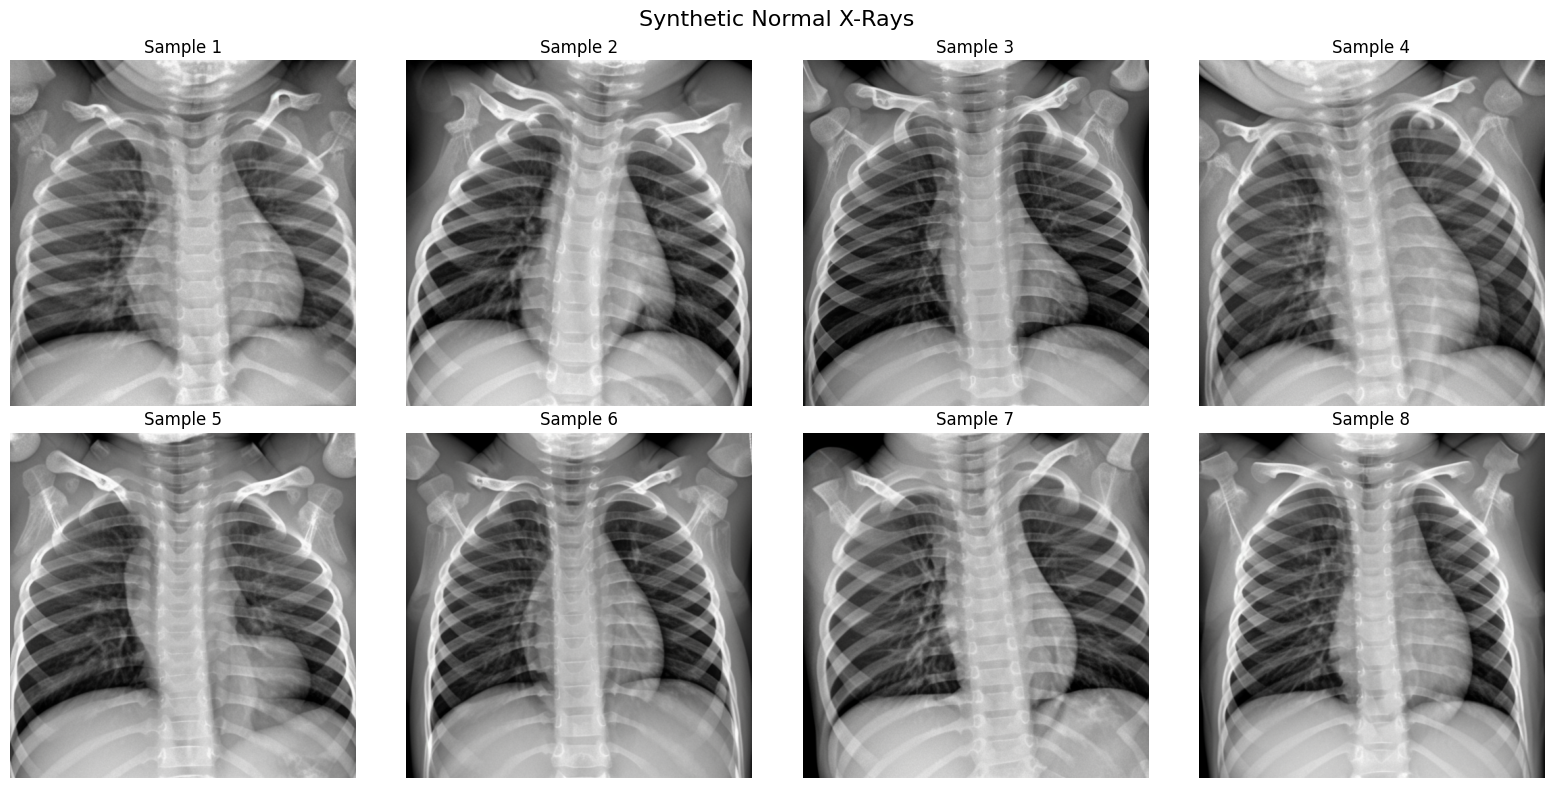

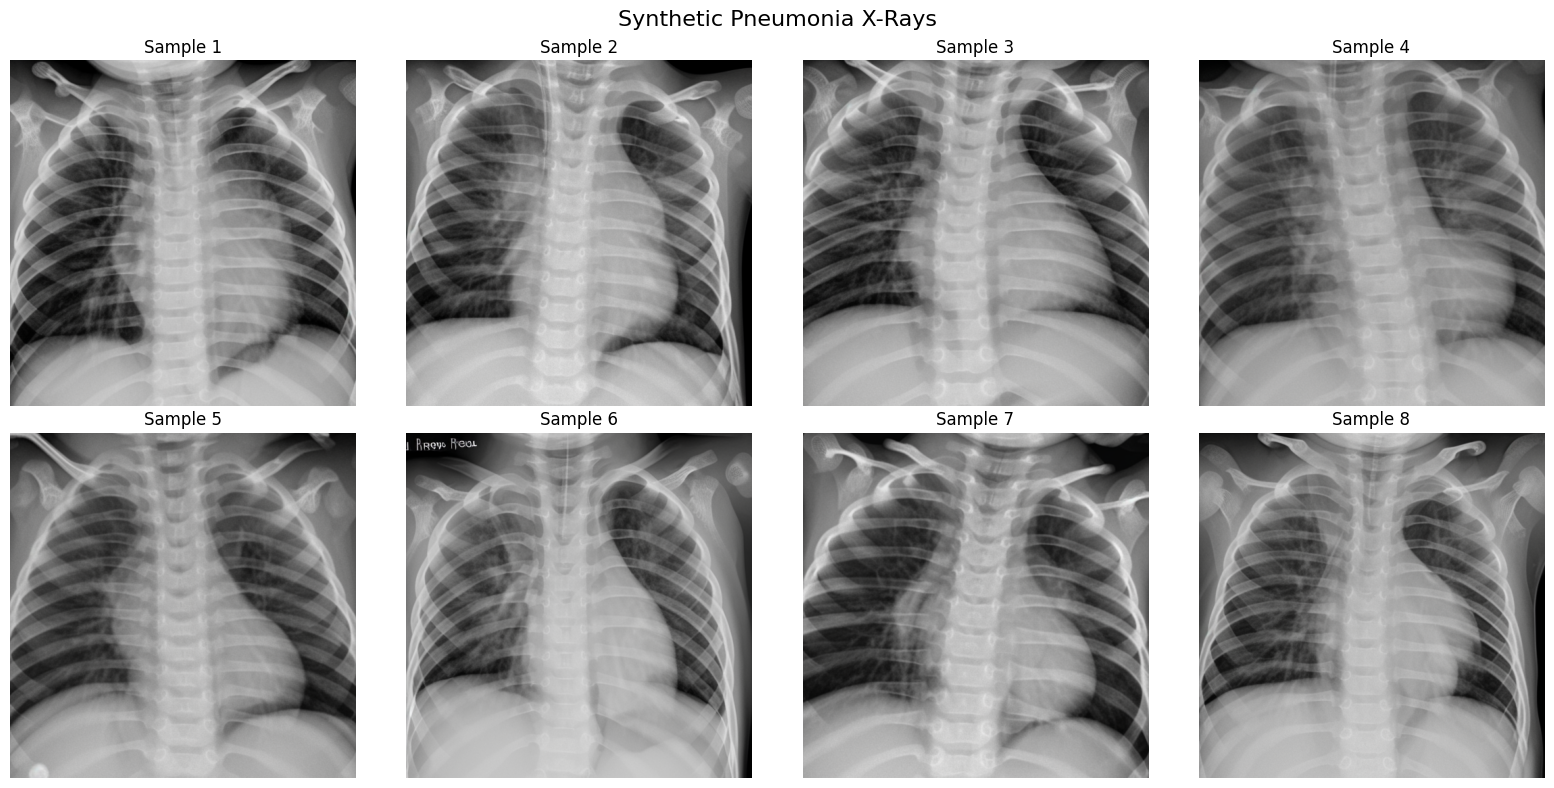

In [ ]:
import os

for class_name in ["normal", "pneumonia"]:
    folder = f"./synthetic_data/{class_name}"
    count = len([f for f in os.listdir(folder) if f.endswith('.png')])
    print(f"{class_name}: {count} images")


# CELL 4: Create a sample grid to preview
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_sample_grid(folder, title, num_samples=8):
    """Display a grid of sample images."""
    files = [f for f in os.listdir(folder) if f.endswith('.png')]
    samples = random.sample(files, min(num_samples, len(files)))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(title, fontsize=16)

    for idx, (ax, filename) in enumerate(zip(axes.flat, samples)):
        img = Image.open(os.path.join(folder, filename))
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(f"Sample {idx+1}")

    plt.tight_layout()
    plt.savefig(f"sample_grid_{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

show_sample_grid("./synthetic_data/normal", "Synthetic Normal X-Rays")
show_sample_grid("./synthetic_data/pneumonia", "Synthetic Pneumonia X-Rays")

In [ ]:
!uv pip install -q pytorch-fid

In [ ]:
from datasets import Dataset, DatasetDict, Image as HFImage, ClassLabel
from huggingface_hub import HfApi
import os

def upload_to_huggingface(
    synthetic_dir: str,
    dataset_name: str = "synthetic-chest-xray-pneumonia",
    username: str = "chimbiwide",
    fid_normal: float = None,
    fid_pneumonia: float = None,
):
    """
    Upload synthetic chest X-ray dataset to HuggingFace Hub.
    """
    print("\n" + "="*60)
    print("UPLOADING TO HUGGING FACE HUB")
    print("="*60)

    # Collect all images and labels
    data = {"image": [], "label": []}

    class_counts = {}
    for label_idx, label_name in enumerate(["normal", "pneumonia"]):
        folder = os.path.join(synthetic_dir, label_name)

        if not os.path.exists(folder):
            print(f"⚠️ Warning: {folder} not found, skipping...")
            continue

        files = sorted([f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[label_name] = len(files)
        print(f"Found {len(files)} {label_name} images")

        for filename in files:
            filepath = os.path.join(folder, filename)
            data["image"].append(filepath)
            data["label"].append(label_idx)

    # Create dataset
    print("\nCreating dataset...")
    dataset = Dataset.from_dict(data)

    # Cast to proper types
    dataset = dataset.cast_column("image", HFImage())
    dataset = dataset.cast_column("label", ClassLabel(names=["normal", "pneumonia"]))

    # Create train/test split (90/10)
    print("Creating train/test split...")
    dataset_dict = dataset.train_test_split(
        test_size=0.1,
        seed=42,
        stratify_by_column="label"
    )

    print(f"\nDataset splits:")
    print(f"  Train: {len(dataset_dict['train'])} images")
    print(f"  Test: {len(dataset_dict['test'])} images")

    # Push to Hub
    repo_id = f"{username}/{dataset_name}"
    print(f"\nUploading to: {repo_id}")

    dataset_dict.push_to_hub(
        repo_id,
        private=False,
        commit_message="Upload synthetic chest X-ray dataset generated with DreamBooth"
    )

    # Create and upload README
    print("Creating README...")

    # Calculate split statistics
    train_normal = sum(1 for x in dataset_dict['train'] if x['label'] == 0)
    train_pneumonia = sum(1 for x in dataset_dict['train'] if x['label'] == 1)
    test_normal = sum(1 for x in dataset_dict['test'] if x['label'] == 0)
    test_pneumonia = sum(1 for x in dataset_dict['test'] if x['label'] == 1)

    fid_normal_str = f"{fid_normal:.2f}" if fid_normal else "TBD"
    fid_pneumonia_str = f"{fid_pneumonia:.2f}" if fid_pneumonia else "TBD"

    readme_content = f"""---
license: cc-by-4.0
task_categories:
  - image-classification
tags:
  - medical
  - chest-x-ray
  - synthetic
  - diffusion-model
  - pneumonia
  - dreambooth
  - stable-diffusion
pretty_name: Synthetic Chest X-Ray Pneumonia Dataset
size_categories:
  - 1K<n<10K
dataset_info:
  features:
    - name: image
      dtype: image
    - name: label
      dtype:
        class_label:
          names:
            '0': normal
            '1': pneumonia
  splits:
    - name: train
      num_examples: {len(dataset_dict['train'])}
    - name: test
      num_examples: {len(dataset_dict['test'])}
---

# Synthetic Chest X-Ray Pneumonia Dataset

## Dataset Description

This dataset contains **synthetic chest X-ray images** generated using Stable Diffusion 2.1
fine-tuned with DreamBooth on the [hf-vision/chest-xray-pneumonia](https://huggingface.co/datasets/hf-vision/chest-xray-pneumonia) dataset.

### Purpose

Created for a science fair project investigating whether synthetic medical images generated
by diffusion models can improve pneumonia classifier accuracy.

### Research Question

> Can synthetic chest X-ray images generated by a finetuned diffusion model improve
> the accuracy of a pneumonia image classifier?

## Dataset Statistics

| Split | Normal | Pneumonia | Total |
|-------|--------|-----------|-------|
| Train | {train_normal} | {train_pneumonia} | {len(dataset_dict['train'])} |
| Test | {test_normal} | {test_pneumonia} | {len(dataset_dict['test'])} |
| **Total** | **{train_normal + test_normal}** | **{train_pneumonia + test_pneumonia}** | **{len(dataset_dict['train']) + len(dataset_dict['test'])}** |

## Generation Details

| Parameter | Value |
|-----------|-------|
| **Base Model** | `stabilityai/stable-diffusion-2-1-base` |
| **Fine-tuning Method** | Full DreamBooth with text encoder training |
| **Resolution** | 512×512 |
| **Inference Steps** | 50 |
| **Guidance Scale** | 4.0 |
| **Scheduler** | DPMSolverMultistepScheduler |

### Fine-tuned Models Used

- Normal: [`chimbiwide/cxr-normal-dreambooth`](https://huggingface.co/chimbiwide/cxr-normal-dreambooth)
- Pneumonia: [`chimbiwide/cxr-pneumonia-dreambooth`](https://huggingface.co/chimbiwide/cxr-pneumonia-dreambooth)

### Generation Prompts

- **Normal**: "a high quality chest xray of healthy normal lungs, clear lung fields, medical radiograph"
- **Pneumonia**: "a high quality chest xray showing pneumonia infection, lung opacity, consolidation visible, medical radiograph"

## Quality Metrics

| Class | FID Score (↓ better) |
|-------|---------------------|
| Normal | {fid_normal_str} |
| Pneumonia | {fid_pneumonia_str} |

## Usage
```python
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("{repo_id}")

# Access splits
train_data = dataset["train"]
test_data = dataset["test"]

# Example: iterate through images
for sample in train_data:
    image = sample["image"]  # PIL Image
    label = sample["label"]  # 0 = normal, 1 = pneumonia
```

### For PyTorch Training
```python
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader

dataset = load_dataset("{repo_id}")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def preprocess(example):
    example["image"] = transform(example["image"].convert("RGB"))
    return example

train_data = dataset["train"].map(preprocess)
train_data.set_format(type="torch", columns=["image", "label"])
```

## Source Dataset

This synthetic dataset was generated from models trained on:
- **Dataset**: [hf-vision/chest-xray-pneumonia](https://huggingface.co/datasets/hf-vision/chest-xray-pneumonia)
- **Original Source**: Pediatric chest X-rays (1-5 years) from Guangzhou Women and Children's Medical Center
- **Citation**: Kermany et al., 2018

## License

This dataset is released under **CC-BY-4.0**, consistent with the source dataset.

## Intended Use

- **Research**: Investigating synthetic data augmentation for medical imaging
- **Education**: Learning about diffusion models and medical image analysis
- **Benchmarking**: Comparing classifier performance with/without synthetic augmentation

## Limitations

- Generated from pediatric X-rays only (ages 1-5)
- May not generalize to adult chest X-rays
- Synthetic images should supplement, not replace, real medical data
- Not intended for clinical diagnosis

## Citation

If you use this dataset, please cite:
```bibtex
@dataset{{synthetic_cxr_2026,
  author = {{David}},
  title = {{Synthetic Chest X-Ray Pneumonia Dataset}},
  year = {{2026}},
  publisher = {{Hugging Face}},
  url = {{https://huggingface.co/datasets/{repo_id}}}
}}
```

And the original dataset:
```bibtex
@article{{kermany2018labeled,
  title={{Labeled optical coherence tomography (OCT) and chest X-ray images for classification}},
  author={{Kermany, Daniel and Goldbaum, Michael and Cai, Wenjia and others}},
  journal={{Mendeley Data}},
  volume={{2}},
  number={{2}},
  year={{2018}}
}}
```
"""

    # Upload README
    api = HfApi()
    api.upload_file(
        path_or_fileobj=readme_content.encode(),
        path_in_repo="README.md",
        repo_id=repo_id,
        repo_type="dataset",
    )

    # Upload sample grid images
    for class_name in ["normal", "pneumonia"]:
        grid_path = f"sample_grid_synthetic_{class_name}_x-rays.png"
        if os.path.exists(grid_path):
            api.upload_file(
                path_or_fileobj=grid_path,
                path_in_repo=f"samples/{class_name}_samples.png",
                repo_id=repo_id,
                repo_type="dataset",
            )

    print(f"\n{'='*60}")
    print(f"UPLOAD COMPLETE!")
    print(f"{'='*60}")
    print(f"Dataset URL: https://huggingface.co/datasets/{repo_id}")

    return repo_id

# CELL 7: Calculate FID scores (optional but recommended)

from pytorch_fid import fid_score
import torch

print("\n" + "="*60)
print("CALCULATING FID SCORES")
print("="*60)

# First, we need the real images to compare against
# Download and prepare real dataset
from datasets import load_dataset
from torchvision import transforms
from PIL import Image
import os

print("\nDownloading real dataset for FID comparison...")
real_dataset = load_dataset("hf-vision/chest-xray-pneumonia")

# Prepare real images
os.makedirs("./real_data/normal", exist_ok=True)
os.makedirs("./real_data/pneumonia", exist_ok=True)

transform = transforms.Compose([
    transforms.Resize(512),
    transforms.CenterCrop(512),
])

print("Preparing real images...")
for idx, sample in enumerate(tqdm(real_dataset['train'], desc="Processing real images")):
    img = sample['image'].convert('RGB')
    img = transform(img)
    label = 'normal' if sample['label'] == 0 else 'pneumonia'
    img.save(f"./real_data/{label}/{idx:05d}.png")

# Calculate FID for each class
print("\nCalculating FID scores...")

fid_normal = fid_score.calculate_fid_given_paths(
    ["./real_data/normal", "./synthetic_data/normal"],
    batch_size=50,
    device=torch.device('cuda'),
    dims=2048,
)
print(f"FID (Normal): {fid_normal:.2f}")

fid_pneumonia = fid_score.calculate_fid_given_paths(
    ["./real_data/pneumonia", "./synthetic_data/pneumonia"],
    batch_size=50,
    device=torch.device('cuda'),
    dims=2048,
)
print(f"FID (Pneumonia): {fid_pneumonia:.2f}")

print(f"\n{'='*60}")
print("FID SCORES SUMMARY")
print(f"{'='*60}")
print(f"Normal:    {fid_normal:.2f}  {'Good' if fid_normal < 50 else 'High'}")
print(f"Pneumonia: {fid_pneumonia:.2f}  {'Good' if fid_pneumonia < 50 else 'High'}")
print(f"\nInterpretation: Lower is better. <20 excellent, <50 good, >100 poor")


# CELL 8: Update HuggingFace README with FID scores
from huggingface_hub import HfApi

api = HfApi()

# Re-upload with FID scores
print("\nUpdating HuggingFace dataset with FID scores...")
upload_to_huggingface(
    synthetic_dir="./synthetic_data",
    dataset_name="synthetic-chest-xray-pneumonia",
    username="chimbiwide",
    fid_normal=fid_normal,
    fid_pneumonia=fid_pneumonia,
)


CALCULATING FID SCORES



README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...etic_pneumonia_x-rays.png:  99%|#########9| 2.62MB / 2.65MB            


✅ UPLOAD COMPLETE!
Dataset URL: https://huggingface.co/datasets/chimbiwide/synthetic-chest-xray-pneumonia


'chimbiwide/synthetic-chest-xray-pneumonia'

In [ ]:
import shutil

# Create zip file
print("Creating zip file...")
shutil.make_archive("synthetic_chest_xrays", 'zip', "./synthetic_data")

# Check zip size
zip_size = os.path.getsize("synthetic_chest_xrays.zip") / (1024 * 1024 * 1024)
print(f"Zip file size: {zip_size:.2f} GB")

# Download to your PC
from google.colab import files
print("\nStarting download...")
files.download("synthetic_chest_xrays.zip")